### 1. perkenalan

Live Code 5

    Nama  : Hiro Kevin
    Batch : CODA-RMT-018

    Program ini dibuat untuk mengevaluasi konsep Time Series Analysis

### 2. import libraries

In [400]:
import pandas as pd
from datetime import date, timedelta
import datetime
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error


### 3. Data loading

In [401]:
df=pd.read_csv('multiTimeline.csv', skiprows=2)

In [402]:
df.head(5)

,Week,Pulau Pari: (Indonesia)
0,2022-03-27,16
1,2022-04-03,13
2,2022-04-10,18
3,2022-04-17,29
4,2022-04-24,35


In [403]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Week                     126 non-null    object
 1   Pulau Pari: (Indonesia)  126 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.1+ KB


In [404]:
df.columns = ['week', 'kedatangan']
              

In [405]:
df['week']=pd.to_datetime(df['week'])

In [406]:
df

,week,kedatangan
0,2022-03-27,16
1,2022-04-03,13
2,2022-04-10,18
3,2022-04-17,29
4,2022-04-24,35
...,...,...
121,2024-07-21,43
122,2024-07-28,34
123,2024-08-04,32
124,2024-08-11,36


In [407]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   week        126 non-null    datetime64[ns]
 1   kedatangan  126 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.1 KB


In [408]:
df.isnull().sum()

week          0
kedatangan    0
dtype: int64

In [409]:
df.set_index('week',inplace=True)

In [410]:
df.describe()

,kedatangan
count,126.000000
mean,32.000000
std,13.919195
min,13.000000
25%,23.000000
50%,29.000000
75%,37.000000
max,100.000000


In [411]:
df.shape

(126, 1)

### 4. EDA

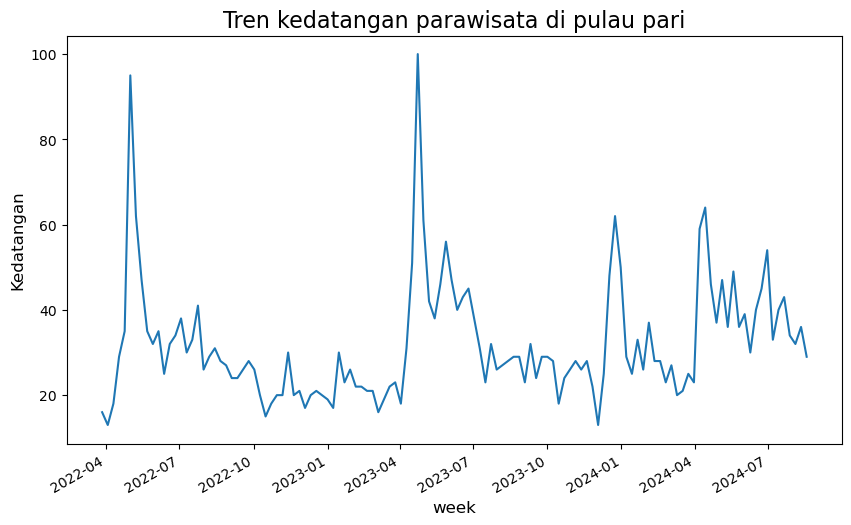

In [412]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df.index,df['kedatangan'])
ax.set_title('Tren kedatangan parawisata di pulau pari', fontsize=16)
ax.set_xlabel('week', fontsize=12)
ax.set_ylabel('Kedatangan', fontsize=12)
fig.autofmt_xdate()
plt.show()

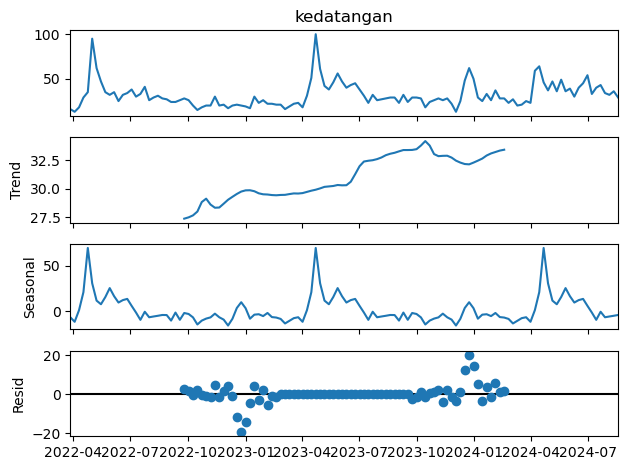

In [413]:
decomposition_m = seasonal_decompose(df['kedatangan'], model='additive', period=52)
fig = decomposition_m.plot()
plt.show()

In [414]:
result = adfuller(df['kedatangan'])

print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -3.8931161743373837
p-value: 0.002086096423020292


In [415]:
df_diff = df['kedatangan'].diff().dropna()
df_diff.head()

week
2022-04-03    -3.0
2022-04-10     5.0
2022-04-17    11.0
2022-04-24     6.0
2022-05-01    60.0
Name: kedatangan, dtype: float64

In [416]:
result = adfuller(df_diff)

print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -9.469858572405302
p-value: 4.1341475008036967e-16


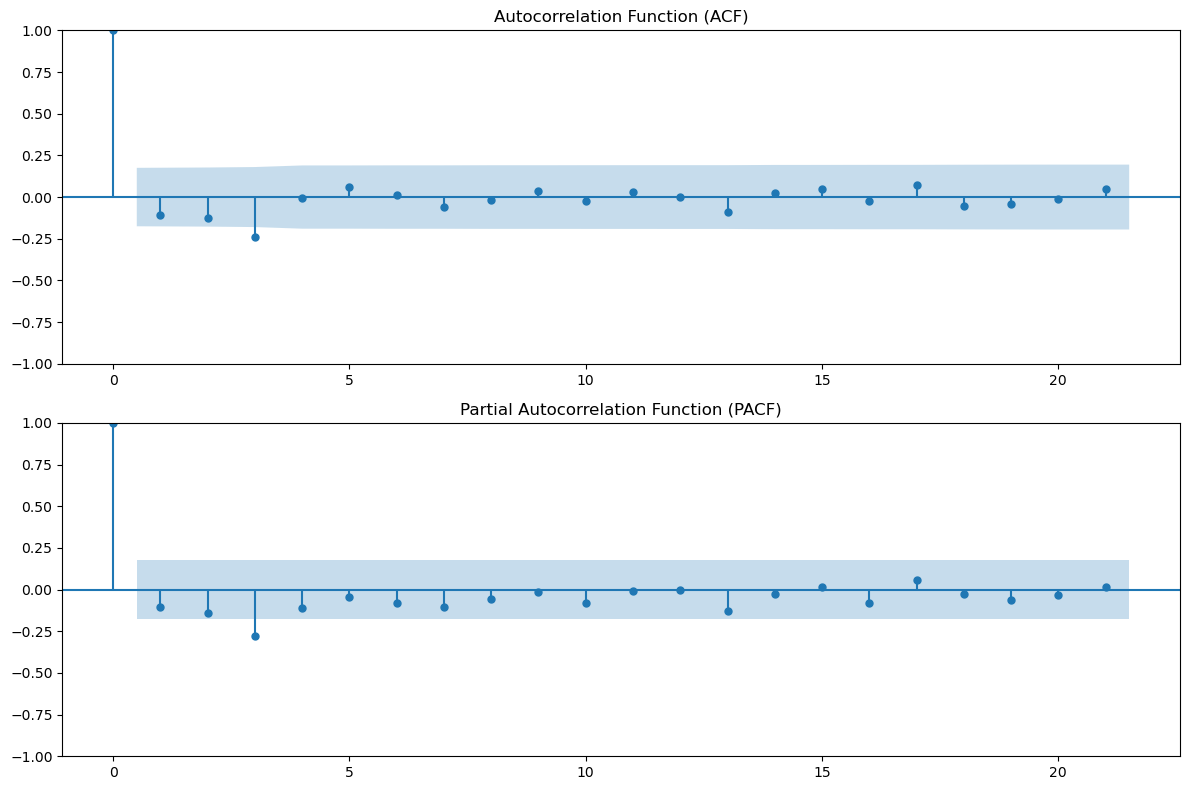

In [417]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(df_diff, ax=ax1)
plot_pacf(df_diff, ax=ax2)
ax1.set_title('Autocorrelation Function (ACF)')
ax2.set_title('Partial Autocorrelation Function (PACF)')
plt.tight_layout()
plt.show()

### 5. Model definiton and training

In [418]:
train_size=int(len(df)*0.8)

train= df['kedatangan'][:train_size]
test = df['kedatangan'][train_size:]

print(f"total train: {train_size}")
print(f"total test: {len(df)-train_size}")
print(len(df['kedatangan']))

total train: 100
total test: 26
126


### 6. Model Evaluation

In [419]:
mae = mean_absolute_error(test, forecast)

print('MAE:', mae)

MAE: 10.194118849147475


### 7. Forecast Model Improvement

In [420]:
def find_best_arima(data: pd.Series, p_range, d_order, q_range):
    """
    Performs a grid search to find the best ARIMA(p,d,q) order.

    Args:
        data (pd.Series): The time series data.
        p_range (range): A range of values for the AR order 'p'.
        d_order (int): The fixed differencing order 'd'.
        q_range (range): A range of values for the MA order 'q'.
    """
    best_aic = float('inf')
    best_order = None
    results = []

    for p in p_range:
        for q in q_range:
            order = (p, d_order, q)
            try:
                model = ARIMA(data, order=order)
                result = model.fit()

                results.append({'Order': order, 'AIC': result.aic})

                if result.aic < best_aic:
                    best_aic = result.aic
                    best_order = order

            except Exception as e:
                continue
    results_df = pd.DataFrame(results).sort_values('AIC').reset_index(drop=True)
    return results_df

In [421]:
p_values = range(2+1)
d_value = 1
q_values = range(2+1)

best_models_df = find_best_arima(df['kedatangan'], p_values, d_value, q_values)

print("Top 5 ARIMA Models by AIC:")
print(best_models_df.head(10))

c:\Users\hiro\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\hiro\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\hiro\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\hiro\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\hiro\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will b

Top 5 ARIMA Models by AIC:
       Order         AIC
0  (1, 1, 1)  957.507879
1  (2, 1, 1)  958.577191
2  (1, 1, 2)  958.727802
3  (2, 1, 2)  961.476288
4  (0, 1, 2)  967.739638
5  (0, 1, 1)  974.404978
6  (0, 1, 0)  974.589847
7  (2, 1, 0)  974.731099
8  (1, 1, 0)  975.175145


c:\Users\hiro\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\hiro\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\hiro\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\hiro\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\hiro\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA p

In [425]:
# Model definition
model = ARIMA(df['kedatangan'], order = (1,1,1))

# Model training
result = model.fit()

result.summary()

c:\Users\hiro\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\hiro\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\hiro\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\hiro\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\hiro\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA p

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:             kedatangan   No. Observations:                  126
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -475.754
Date:                Mon, 25 May 2026   AIC                            957.508
Time:                        22:02:25   BIC                            965.993
Sample:                    03-27-2022   HQIC                           960.955
                         - 08-18-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6479      0.068      9.483      0.000       0.514       0.782
ma.L1         -0.9998      4.022     -0.249      0.804      -8.882       6.883
sigma2       115.3286    463.842      0.249      0.804    -793.785    1024.442
===================================================================================
Ljung-Box (L1) (Q):                   0.32   Jarque-Bera (JB):               933.68
Prob(Q):                              0.57   Prob(JB):                         0.00
Heteroskedasticity (H):               0.82   Skew:                             2.84
Prob(H) (two-sided):                  0.52   Kurtosis:                        15.12
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""